In [4]:
# ==========================================================
# 🧹 Data Cleaning – Drop Unnecessary Columns (Actual Columns)
# ==========================================================
import pandas as pd

# --- Load CSVs ---
users_df   = pd.read_csv("dataset/users.csv")
hotels_df  = pd.read_csv("dataset/hotels.csv")
reviews_df = pd.read_csv("dataset/reviews.csv")

# --- Drop unneeded columns ---
users_drop_cols   = ["join_date"]  # optional
hotels_drop_cols  = ["hotel_name", "star_rating", "lat", "lon"]
reviews_drop_cols = ["review_text"]  # only if exists

users_df.drop(columns=users_drop_cols, errors='ignore', inplace=True)
hotels_df.drop(columns=hotels_drop_cols, errors='ignore', inplace=True)
reviews_df.drop(columns=reviews_drop_cols, errors='ignore', inplace=True)

# --- Show updated shapes ---
print(f"✅ Users dataframe shape after drop  : {users_df.shape}")
print(f"✅ Hotels dataframe shape after drop : {hotels_df.shape}")
print(f"✅ Reviews dataframe shape after drop: {reviews_df.shape}")

# --- Quick preview ---
display(users_df.head())
display(hotels_df.head())
display(reviews_df.head())


✅ Users dataframe shape after drop  : (2000, 5)
✅ Hotels dataframe shape after drop : (25, 9)
✅ Reviews dataframe shape after drop: (50000, 11)


,user_id,user_gender,country,age_group,traveller_type
0,1,Female,United Kingdom,35-44,Solo
1,2,Male,United Kingdom,25-34,Solo
2,3,Female,Mexico,25-34,Family
3,4,Male,India,35-44,Family
4,5,Other,Japan,25-34,Solo


,hotel_id,city,country,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,New York,United States,9.1,8.8,8.9,9.5,8.6,8.0
1,2,London,United Kingdom,9.0,9.2,8.8,9.4,9.0,7.9
2,3,Paris,France,8.8,9.4,8.7,9.6,9.3,8.1
3,4,Tokyo,Japan,9.6,9.0,9.3,8.5,9.5,8.2
4,5,Dubai,United Arab Emirates,9.3,9.5,9.6,8.9,9.4,8.5


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9


In [16]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("dataset")

users   = pd.read_csv(DATA_DIR / "users.csv")
hotels  = pd.read_csv(DATA_DIR / "hotels.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")

print("Loaded -> users:", users.shape, "| hotels:", hotels.shape, "| reviews:", reviews.shape)

# ==========================================================
# 🔗 Data Merging – Combine Users, Hotels, and Reviews
# ==========================================================

# --- Merge reviews with users on user_id ---
merged_df = pd.merge(reviews_df, users_df, on="user_id", how="left")

# --- Merge the result with hotels on hotel_id ---
merged_df = pd.merge(merged_df, hotels_df, on="hotel_id", how="left")

# --- Show shape and preview ---
print(f"✅ Final merged dataset shape: {merged_df.shape}")
display(merged_df.head())

# --- Optional sanity check ---
print("\nMissing values per column:")
print(merged_df.isnull().sum())

# --- Save merged dataset (for later use) ---
merged_df.to_csv("dataset/hotel_reviews_merged.csv", index=False)
print("\n💾 Merged dataset saved to: dataset/hotel_reviews_merged.csv")


Loaded -> users: (2000, 6) | hotels: (25, 13) | reviews: (50000, 12)
✅ Final merged dataset shape: (50000, 23)


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money,user_gender,country_x,age_group,traveller_type,city,country_y,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7,Female,New Zealand,25-34,Solo,New York,United States,9.1,8.8,8.9,9.5,8.6,8.0
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6,Female,United Kingdom,35-44,Couple,Tokyo,Japan,9.6,9.0,9.3,8.5,9.5,8.2
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6,Female,Spain,55+,Couple,Cairo,Egypt,8.8,8.7,8.6,9.1,8.7,8.4
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3,Female,United Kingdom,35-44,Business,Barcelona,Spain,9.2,9.1,8.9,9.7,9.0,8.8
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9,Male,Australia,45-54,Family,Moscow,Russia,9.1,9.3,9.0,9.0,9.1,8.6



Missing values per column:
review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
user_gender              0
country_x                0
age_group                0
traveller_type           0
city                     0
country_y                0
cleanliness_base         0
comfort_base             0
facilities_base          0
location_base            0
staff_base               0
value_for_money_base     0
dtype: int64

💾 Merged dataset saved to: dataset/hotel_reviews_merged.csv


C:\Users\mohan\AppData\Local\Temp\ipykernel_10984\1464983569.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_block)


,traveller_type,city,n,mean_composite,median_composite,std,ci95,mean_delta,total_n,min_n_type,rank
47,Business,Amsterdam,460.0,8.899565,8.900000,0.120082,0.010974,-0.311232,10371,104,1
34,Couple,Dubai,706.0,9.050121,9.057143,0.115456,0.008517,-0.156067,17240,173,1
72,Family,Dubai,452.0,9.194817,9.200000,0.118566,0.010931,-0.008444,11945,120,1
82,Solo,Dubai,443.0,9.091938,9.085714,0.117770,0.010967,-0.109481,10444,105,1


,traveller_type,city,n,mean_composite,median_composite,std,ci95,mean_delta,total_n,min_n_type,rank
47,Business,Amsterdam,460.0,8.899565,8.900000,0.120082,0.010974,-0.311232,10371,104,1
38,Business,Dubai,434.0,8.892758,8.900000,0.122072,0.011485,-0.319393,10371,104,2
7,Business,Singapore,407.0,8.852018,8.842857,0.119745,0.011634,-0.296724,10371,104,3
34,Couple,Dubai,706.0,9.050121,9.057143,0.115456,0.008517,-0.156067,17240,173,1
43,Couple,Amsterdam,631.0,9.049808,9.057143,0.116647,0.009102,-0.158056,17240,173,2
15,Couple,Singapore,700.0,9.006694,9.000000,0.120598,0.008934,-0.133452,17240,173,3
72,Family,Dubai,452.0,9.194817,9.200000,0.118566,0.010931,-0.008444,11945,120,1
67,Family,Amsterdam,444.0,9.186937,9.185714,0.117887,0.010966,-0.014602,11945,120,2
17,Family,Shanghai,481.0,9.152094,9.157143,0.118217,0.010565,0.017256,11945,120,3
82,Solo,Dubai,443.0,9.091938,9.085714,0.117770,0.010967,-0.109481,10444,105,1


💾 Saved: dataset/out_best_city_per_traveller_type.csv
💾 Saved: dataset/out_top3_cities_per_traveller_type.csv
💾 Saved: dataset/out_all_city_stats.csv


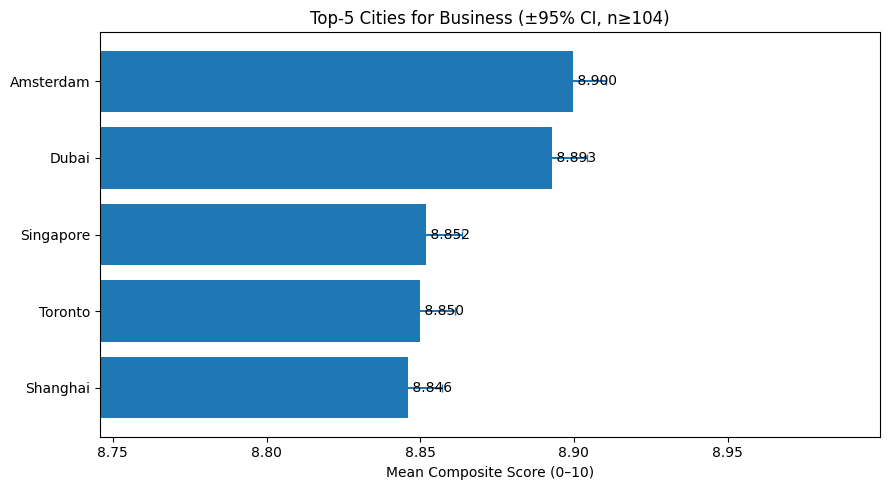

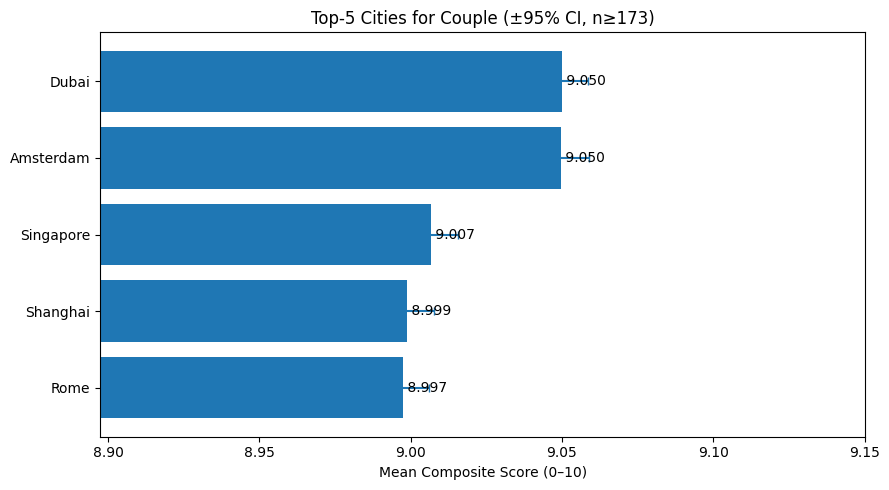

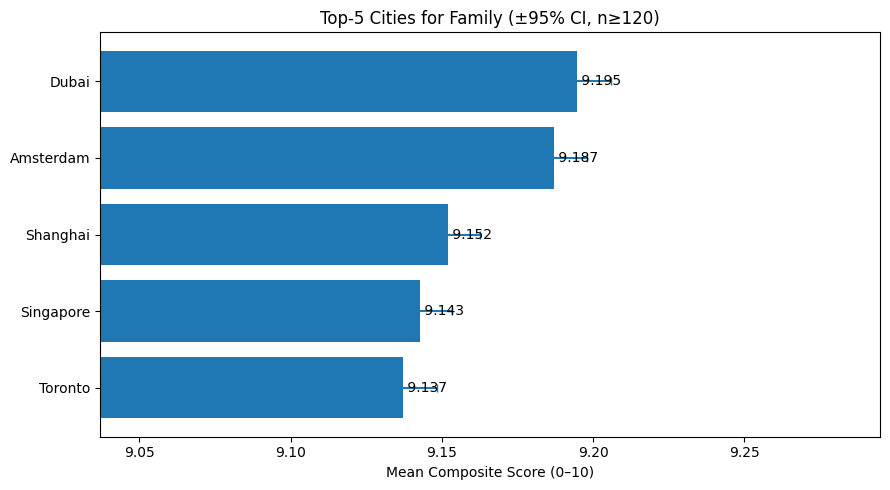

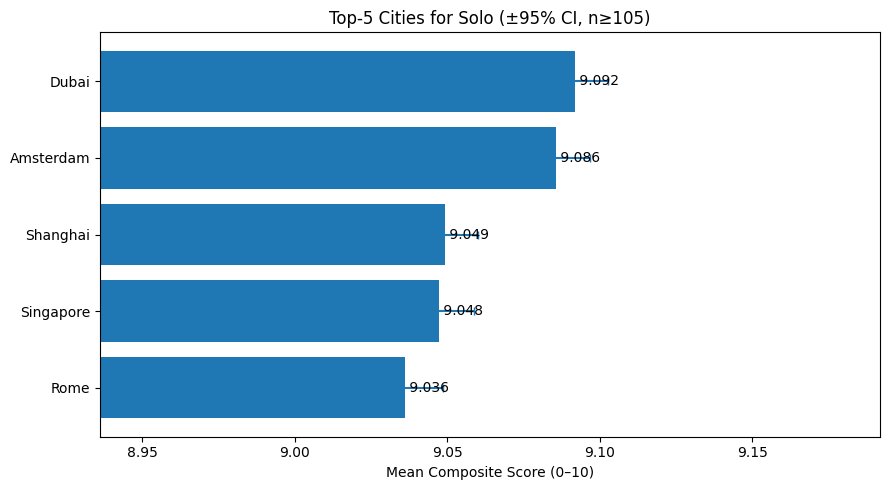

🖼️ Saved charts:
   - dataset/plot_top5_business.png
   - dataset/plot_top5_couple.png
   - dataset/plot_top5_family.png
   - dataset/plot_top5_solo.png
🖼️ Saved chart: dataset/plot_winners_summary.png


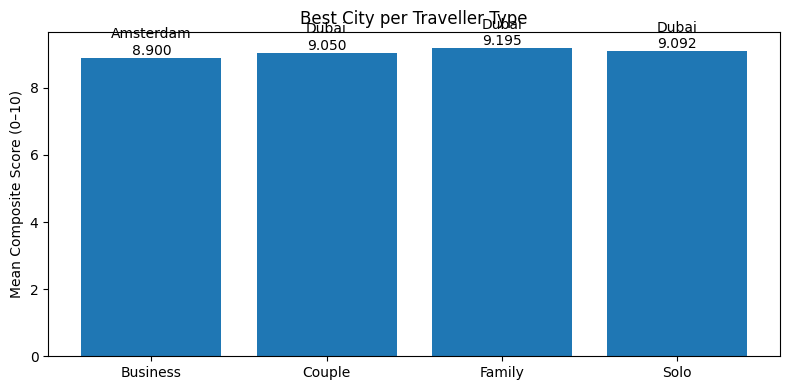

In [18]:
# ==========================================================
# Which city is best for each traveller_type?
# End-to-end: load → prep → aggregate → rank → visualize → save
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, ceil

# ---------- 1) Load & tidy ----------
DATA_PATH = "dataset/hotel_reviews_merged.csv"
df = pd.read_csv(DATA_PATH)

# explicit names
df = df.rename(columns={"country_x": "user_country", "country_y": "hotel_country"})
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

score_cols = [
    "score_overall","score_cleanliness","score_comfort","score_facilities",
    "score_location","score_staff","score_value_for_money"
]
base_cols = [
    "cleanliness_base","comfort_base","facilities_base",
    "location_base","staff_base","value_for_money_base"
]

# keep only rows we can use
df = df.dropna(subset=["traveller_type","city"])
# defensive: clip scores to [0,10]
for c in score_cols:
    if c in df.columns:
        df[c] = df[c].clip(0, 10)

# ---------- 2) Metrics ----------
# Composite 0..10
df["composite"] = df[score_cols].mean(axis=1)

# Delta vs hotel baselines (how much reviews beat/lag the hotel's base)
df["delta_mean"] = (
    pd.concat([
        df["score_cleanliness"]     - df["cleanliness_base"],
        df["score_comfort"]         - df["comfort_base"],
        df["score_facilities"]      - df["facilities_base"],
        df["score_location"]        - df["location_base"],
        df["score_staff"]           - df["staff_base"],
        df["score_value_for_money"] - df["value_for_money_base"],
    ], axis=1)
    .mean(axis=1)
)

# ---------- 3) Aggregate per (traveller_type, city) ----------
def agg_block(g: pd.DataFrame) -> pd.Series:
    n   = g.shape[0]
    m   = g["composite"].mean()
    med = g["composite"].median()
    sd  = g["composite"].std(ddof=1)
    ci  = 1.96 * (sd / sqrt(n)) if n >= 30 and pd.notna(sd) else np.nan  # normal approx
    m_delta = g["delta_mean"].mean()
    return pd.Series({
        "n": n,
        "mean_composite": m,
        "median_composite": med,
        "std": sd,
        "ci95": ci,
        "mean_delta": m_delta
    })

agg = (
    df.groupby(["traveller_type","city"], as_index=False, sort=False)
      .apply(agg_block)
      .reset_index(drop=True)
)

# ---------- 4) Minimum sample size (per-type) ----------
# auto-tune: at least 30, or 1% of that traveller_type's total reviews (whichever is larger)
type_counts = df.groupby("traveller_type").size().rename("total_n")
agg = agg.merge(type_counts, on="traveller_type", how="left")
agg["min_n_type"] = (agg["total_n"] * 0.01).apply(lambda x: max(30, int(ceil(x))))
agg = agg[agg["n"] >= agg["min_n_type"]].copy()

# ---------- 5) Rank within traveller_type ----------
# Tie-breakers: mean desc, n desc, median desc, city asc (deterministic)
agg = agg.sort_values(
    ["traveller_type","mean_composite","n","median_composite","city"],
    ascending=[True, False, False, False, True]
)
agg["rank"] = agg.groupby("traveller_type").cumcount() + 1

winners = agg[agg["rank"] == 1].copy()
top3    = agg[agg["rank"] <= 3].copy()

# Show in notebook
display(winners.sort_values("traveller_type"))
display(top3.sort_values(["traveller_type","rank","city"]))

# Save tabular outputs
winners_path = "dataset/out_best_city_per_traveller_type.csv"
top3_path    = "dataset/out_top3_cities_per_traveller_type.csv"
agg_path     = "dataset/out_all_city_stats.csv"

winners.to_csv(winners_path, index=False)
top3.to_csv(top3_path, index=False)
agg.drop(columns=["total_n","min_n_type"]).to_csv(agg_path, index=False)

print(f"💾 Saved: {winners_path}")
print(f"💾 Saved: {top3_path}")
print(f"💾 Saved: {agg_path}")

# ---------- 6) Visuals ----------
# Top-5 per traveller_type (bars with CI labels)
top5 = (
    agg.sort_values(["traveller_type","mean_composite","n"], ascending=[True, False, False])
       .groupby("traveller_type")
       .head(5)
)

plot_paths = []
for ttype, sub in top5.groupby("traveller_type"):
    sub = sub.sort_values("mean_composite", ascending=True)
    y = np.arange(len(sub))

    plt.figure(figsize=(9, 5))
    bars = plt.barh(y, sub["mean_composite"])  # default color, no style
    # CI bars if available
    if sub["ci95"].notna().any():
        plt.errorbar(sub["mean_composite"], y, xerr=sub["ci95"].fillna(0), fmt='none', capsize=3)

    # annotate values
    for i, v in enumerate(sub["mean_composite"]):
        plt.text(v, i, f" {v:.3f}", va="center")

    # zoom x-range to useful window
    lo = max(0, sub["mean_composite"].min() - 0.1)
    hi = min(10, sub["mean_composite"].max() + 0.1)
    plt.xlim(lo, hi)

    plt.yticks(y, sub["city"])
    plt.xlabel("Mean Composite Score (0–10)")
    min_n = int(sub["min_n_type"].iloc[0])
    plt.title(f"Top-5 Cities for {ttype} (±95% CI, n≥{min_n})")
    plt.tight_layout()

    out_png = f"dataset/plot_top5_{ttype.replace(' ','_').lower()}.png"
    plt.savefig(out_png, dpi=150)
    plot_paths.append(out_png)
    plt.show()

print("🖼️ Saved charts:")
for p in plot_paths:
    print("   -", p)

# ---------- 7) Winners summary chart (one bar per traveller_type) ----------
# Useful for the report: shows best city per type side-by-side.
win_plot = winners.sort_values("traveller_type").copy()
plt.figure(figsize=(8, 4))
x = np.arange(win_plot.shape[0])
plt.bar(x, win_plot["mean_composite"])
for i, (city, val) in enumerate(zip(win_plot["city"], win_plot["mean_composite"])):
    plt.text(i, val, f"{city}\n{val:.3f}", ha="center", va="bottom")

plt.xticks(x, win_plot["traveller_type"], rotation=0)
plt.ylabel("Mean Composite Score (0–10)")
plt.title("Best City per Traveller Type")
plt.tight_layout()
out_png = "dataset/plot_winners_summary.png"
plt.savefig(out_png, dpi=150)
print("🖼️ Saved chart:", out_png)
plt.show()
